# Formula 1 2024 Qualifying vs Race Analysis

## Project Objective

This project investigates the relationship between Formula 1 qualifying positions and race results during the 2024 season.

The analysis explores:

- Driver performance trends
- Team performance trends
- Position gains and losses
- Whether qualifying position predicts race finishing position

Tools Used:
- Python
- Pandas
- Matplotlib
- Scikit-Learn

## Data Loading

In [2]:
import pandas as pd
df = pd.read_csv('qualifying.csv')
df.head()

,Track,Position,No,Driver,Team,Q1,Q2,Q3,Laps
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1:30.031,1:29.374,1:29.179,17
1,Bahrain,2,16,Charles Leclerc,Ferrari,1:30.243,1:29.165,1:29.407,19
2,Bahrain,3,63,George Russell,Mercedes,1:30.350,1:29.922,1:29.485,17
3,Bahrain,4,55,Carlos Sainz,Ferrari,1:29.909,1:29.573,1:29.507,18
4,Bahrain,5,11,Sergio Perez,Red Bull Racing Honda RBPT,1:30.221,1:29.932,1:29.537,17


In [3]:
df.shape


(478, 9)

In [4]:
df.dtypes

,0
Track,object
Position,object
No,int64
Driver,object
Team,object
Q1,object
Q2,object
Q3,object
Laps,int64


In [5]:
df.groupby('Driver')['Position'].count()

,Position
Driver,
Alexander Albon,24
Carlos Sainz,23
Charles Leclerc,24
Daniel Ricciardo,18
Esteban Ocon,23
Fernando Alonso,24
Franco Colapinto,9
George Russell,24
Guanyu Zhou,24


In [6]:
df[df['Driver']=='Sergio Perez']['Position'].value_counts()

,count
Position,
16,4
3,3
8,3
5,2
4,2
2,2
10,2
13,2
19,1


## Data Cleaning

The qualifying dataset is cleaned by converting position values to numeric format and handling invalid values.

In [7]:
df['Position']=pd.to_numeric(df['Position'], errors ='coerce')

## Qualifying Performance Analysis

This section explores driver and team performance during qualifying sessions.

In [8]:
df.groupby('Team')['Position'].mean()

,Position
Team,
Alpine Renault,13.893617
Aston Martin Aramco Mercedes,11.208333
Ferrari,5.541667
Haas Ferrari,12.956522
Kick Sauber Ferrari,16.489362
McLaren Mercedes,4.479167
Mercedes,6.833333
RB Honda RBPT,12.083333
Red Bull Racing Honda RBPT,6.083333


## Race Data Preparation

The race dataset is loaded and prepared for comparison with qualifying results.

In [9]:
df_race=pd.read_csv('race.csv')

In [10]:
df_race.dtypes

,0
Track,object
Position,object
No,int64
Driver,object
Team,object
Starting Grid,int64
Laps,int64
Time/Retired,object
Points,int64
Set Fastest Lap,object


In [11]:
df_race['Position']=pd.to_numeric(df_race['Position'], errors ='coerce')

## Dataset Merging

The qualifying and race datasets are merged using Driver and Track information.

In [12]:
df_merged=df_race.merge(df, on = ['Driver','Track'], suffixes = ('_race','_quali'))
df_merged.head()

,Track,Position_race,No_race,Driver,Team_race,Starting Grid,Laps_race,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time,Position_quali,No_quali,Team_quali,Q1,Q2,Q3,Laps_quali
0,Bahrain,1.0,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:31:44.742,26,Yes,1:32.608,1.0,1,Red Bull Racing Honda RBPT,1:30.031,1:29.374,1:29.179,17
1,Bahrain,2.0,11,Sergio Perez,Red Bull Racing Honda RBPT,5,57,+22.457,18,No,1:34.364,5.0,11,Red Bull Racing Honda RBPT,1:30.221,1:29.932,1:29.537,17
2,Bahrain,3.0,55,Carlos Sainz,Ferrari,4,57,+25.110,15,No,1:34.507,4.0,55,Ferrari,1:29.909,1:29.573,1:29.507,18
3,Bahrain,4.0,16,Charles Leclerc,Ferrari,2,57,+39.669,12,No,1:34.090,2.0,16,Ferrari,1:30.243,1:29.165,1:29.407,19
4,Bahrain,5.0,63,George Russell,Mercedes,3,57,+46.788,10,No,1:35.065,3.0,63,Mercedes,1:30.350,1:29.922,1:29.485,17


## Position Gain Analysis

Position gain measures how many places a driver gained or lost between qualifying and the race.

In [13]:
df_merged['Position_Gain']=df_merged['Position_quali']-df_merged['Position_race']

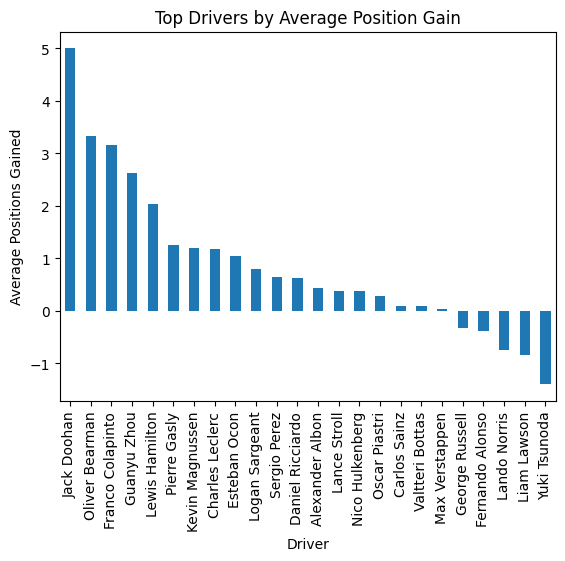

In [29]:
top_gainers = (df_merged.groupby('Driver')['Position_Gain'].mean().sort_values(ascending=False))
top_gainers.plot(kind='bar')
plt.title('Top Drivers by Average Position Gain')
plt.ylabel('Average Positions Gained')
plt.show()

In [14]:
df_merged.groupby('Driver')['Position_Gain'].mean().sort_values(ascending=False)

,Position_Gain
Driver,
Jack Doohan,5.000000
Oliver Bearman,3.333333
Franco Colapinto,3.166667
Guanyu Zhou,2.619048
Lewis Hamilton,2.045455
Pierre Gasly,1.263158
Kevin Magnussen,1.190476
Charles Leclerc,1.173913
Esteban Ocon,1.047619


## Regression Analysis

A linear regression model is used to evaluate whether qualifying position can predict race finishing position.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np


In [16]:
df_clean=df_merged[['Position_quali','Position_race','Driver','Track']].dropna()

In [17]:
x= df_clean[['Position_quali']]
y=df_clean['Position_race']

In [18]:
model = LinearRegression()

In [19]:
model.fit(x,y)

LinearRegression()

In [20]:
print(f"Coefficient: {model.coef_[0]:.3f}" )

Coefficient: 0.746


In [21]:
print(f"Intercept: {model.intercept_:.3f}")

Intercept: 1.999


In [22]:
print(f"R2: {r2_score(y,model.predict(x)): .3f}")

R2:  0.642


## Visualization

The relationship between qualifying position and race finishing position is visualized using a scatter plot and regression line.

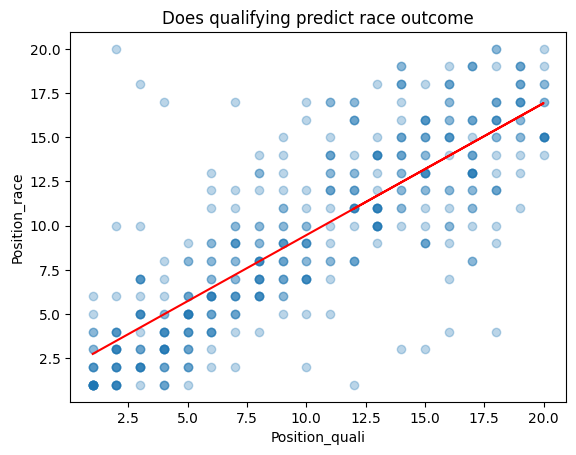

In [23]:
plt.scatter(x,y,alpha=0.3)
plt.plot(x,model.predict(x),color ='red')
plt.xlabel('Position_quali')
plt.ylabel('Position_race')
plt.title('Does qualifying predict race outcome')
plt.show()

In [26]:
df_clean['predicted'] = model.predict(df_clean[['Position_quali']])

df_clean['residual'] = (df_clean['Position_race'] - df_clean['predicted'])

df_clean.sort_values('residual').head(10)[['Driver','Track','Position_quali','Position_race','residual']]


,Driver,Track,Position_quali,Position_race,residual
461,Lewis Hamilton,Abu Dhabi,18.0,4.0,-11.434745
400,Pierre Gasly,Brazil,15.0,3.0,-10.195379
398,Max Verstappen,Brazil,12.0,1.0,-9.956014
321,Lando Norris,Azerbaijan,16.0,4.0,-9.941834
460,Charles Leclerc,Abu Dhabi,14.0,3.0,-9.448924
419,Lewis Hamilton,Las Vegas,10.0,2.0,-7.463103
245,Sergio Perez,Hungary,16.0,7.0,-6.941834
246,George Russell,Hungary,17.0,8.0,-6.688290
385,Oscar Piastri,Mexico,17.0,8.0,-6.688290
87,Lewis Hamilton,China,18.0,9.0,-6.434745


In [31]:
top_underperformers = (df_clean.sort_values('residual', ascending=False)[['Driver','Track','Position_quali','Position_race','residual']])
top_underperformers.head(10)

,Driver,Track,Position_quali,Position_race,residual
218,Lando Norris,Austria,2.0,20.0,16.508539
335,Carlos Sainz,Azerbaijan,3.0,18.0,13.762084
334,Sergio Perez,Azerbaijan,4.0,17.0,12.015628
56,George Russell,Australia,7.0,17.0,9.776263
314,Nico Hulkenberg,Italy,10.0,17.0,7.536897
434,Esteban Ocon,Las Vegas,11.0,17.0,6.790442
115,Lance Stroll,Miami,11.0,17.0,6.790442
356,Kevin Magnussen,Singapore,14.0,19.0,6.551076
336,Lance Stroll,Azerbaijan,14.0,19.0,6.551076
15,Nico Hulkenberg,Bahrain,10.0,16.0,6.536897


In [32]:
top_overperformers = ( df_clean.sort_values('residual')[['Driver','Track','Position_quali','Position_race','residual']])
top_overperformers.head(10)

,Driver,Track,Position_quali,Position_race,residual
461,Lewis Hamilton,Abu Dhabi,18.0,4.0,-11.434745
400,Pierre Gasly,Brazil,15.0,3.0,-10.195379
398,Max Verstappen,Brazil,12.0,1.0,-9.956014
321,Lando Norris,Azerbaijan,16.0,4.0,-9.941834
460,Charles Leclerc,Abu Dhabi,14.0,3.0,-9.448924
419,Lewis Hamilton,Las Vegas,10.0,2.0,-7.463103
245,Sergio Perez,Hungary,16.0,7.0,-6.941834
246,George Russell,Hungary,17.0,8.0,-6.688290
385,Oscar Piastri,Mexico,17.0,8.0,-6.688290
87,Lewis Hamilton,China,18.0,9.0,-6.434745


In [27]:
print(df.shape)
print(df_race.shape)
print(df_merged.shape)

(478, 9)
(479, 11)
(478, 19)


# Key Findings

### 1. Qualifying position is strongly related to race result

Drivers starting near the front generally finish near the front.

### 2. Some drivers consistently gain positions

Position gain analysis identifies drivers who outperform their qualifying results.

### 3. Team performance varies significantly

Average qualifying positions highlight the strongest and weakest teams.

### 4. Regression analysis confirms the relationship

The linear model demonstrates a positive relationship between qualifying position and race finishing position.

# Future Improvements

- Analyze multiple seasons
- Include weather conditions
- Include pit stop strategies
- Compare sprint and main race performance